# Dogs vs Cats
This notebook runs Part 1: baseline Dogs vs Cats classifiers under identity and fixed tile-wise permutations.


## Setup

### Global / External Imports
Import third-party libraries used only for notebook orchestration and display.


most basic imports

In [1]:
import sys, os
from pathlib import Path
import socket

### Local Imports
Import project modules. Part 1 orchestration lives in this notebook; reusable training, preprocessing, and evaluation helpers stay in `src`.


prep for local imports

In [2]:
def get_project_root() -> str:
    project_root = '/Users/royrubin/Documents/GitHub/MLDS_Final_Project'

    if socket.gethostname() != 'MACs-MacBook-Pro.local':
        try:
            from google.colab import drive  # type: ignore # this import is only available in Colab, so if it succeeds we're in Colab
            # mount drive
            drive.mount('/content/drive')
            project_root = '/content/drive/MyDrive/MLDS_Final_Project'
        except Exception as e:
            raise RuntimeError(f"Error mounting Google Drive: {e}")

    return project_root

# Add project root to sys.path so we can import modules from src
REPO_PATH = get_project_root()
if str(REPO_PATH) not in sys.path:
    sys.path.insert(0, str(REPO_PATH))

print(f"Project root: {REPO_PATH}")

Project root: /Users/royrubin/Documents/GitHub/MLDS_Final_Project


make local imports

In [3]:
import importlib
from src.utils.config import CVExperimentConfig
from src.evaluation.experiment_results import (
    experiment_output_paths,
    get_device,
    load_experiment_samples,
    plot_accuracy_vs_tiles,
    save_aggregated_accuracy,
    save_rows,
)
import src.training.experiment_steps as experiment_steps

experiment_steps = importlib.reload(experiment_steps)
collect_model_permutation_results = experiment_steps.collect_model_permutation_results
from src.preprocessing.dogs_cats import class_counts
from src.preprocessing.permutations import build_permutation_records
from src.utils.io import ensure_dir, save_csv
from src.utils.plotting import plot_permutation_samples
from src.utils.reproducibility import seed_everything

/Users/royrubin/opt/anaconda3/envs/mlds_dogs_vs_cats/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Setup configs

In [4]:
configs = CVExperimentConfig()
display(configs)

CVExperimentConfig(part='part1', config_name='part1_baselines', device='auto', deterministic=False, root_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project', data_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project/data/dogs-vs-cats/train', outputs_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs', results_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results', figures_dir='/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/figures', sample_data=True, sample_limit=256, val_fraction=0.2, test_fraction=0.0, image_size=224, batch_size=16, num_workers=2, num_classes=2, model_names=['resnet18', 'swin_t', 'convmixer'], pretrained=False, convmixer_dim=128, convmixer_depth=4, grid_sizes=[1, 2, 3, 4], num_permutations=2, epochs=1, learning_rate=0.0003, optimizer='adamw', weight_decay=0.0001, use_amp=False, seed=42, max_threads=4, using_google_colab=False, plot_samples=False)

### make installations before final external imports

In [5]:
# Make relevant instalation only if using collab (otherwise, already installed)
from gettext import install

import pip


os.chdir(REPO_PATH)
%pip install -r requirements.txt

if configs.using_google_colab:
    # Install PyTorch with CUDA support in Colab
    %pip uninstall -y torch torchvision
    %pip install --index-url https://download.pytorch.org/whl/cu118 torch torchvision

Note: you may need to restart the kernel to use updated packages.


### final imports (after doing pip install if working on colab)

In [6]:
import json
import random
from IPython.display import Image, display
import pandas as pd
import numpy as np
import torch


## Experiments

### Experiment helpers
Shared helpers are kept in `src/evaluation/experiment_results.py`; notebook-specific helpers stay here.

In [7]:
def get_part1_output_paths(*, config: CVExperimentConfig) -> dict[str, str]:
    """Build stable Part 1 output paths for notebook display."""
    paths = experiment_output_paths(
        results_dir=config.results_dir,
        figures_dir=config.figures_dir,
        part_name='part1',
    )
    paths['accuracy_plot'] = paths['figure']
    return paths

### Setup Exp

In [8]:
# 4. Reproducibility (important for multiple notebooks
random.seed(configs.seed)
np.random.seed(configs.seed)
torch.manual_seed(configs.seed)
torch.set_num_threads(configs.max_threads)  # avoid contention across notebooks

In [9]:
output_paths = get_part1_output_paths(config=configs)
output_paths

{'raw_results': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results/part1_raw_results.csv',
 'aggregated_results': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results/part1_aggregated_results.csv',
 'figure': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/figures/part1_accuracy_vs_tiles.png',
 'permutations': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results/part1_permutations.csv',
 'accuracy_plot': '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/figures/part1_accuracy_vs_tiles.png'}

### Data Loading
Discover the configured Dogs vs Cats split before training.


In [10]:
if not configs.using_google_colab:
    configs.sample_data = True
    configs.sample_limit = 32
    configs.grid_sizes = [1, 2]
    configs.num_permutations = 1
    configs.plot_samples = True

train_samples, validation_samples, test_samples = load_experiment_samples(config=configs, seed=configs.seed)
print(f'Train samples: {len(train_samples)}')
print(f'Validation samples: {len(validation_samples)}')
print(f'Test samples: {len(test_samples)}')
print('Train class counts:', class_counts(samples=train_samples))
print('Validation class counts:', class_counts(samples=validation_samples))
print('Test class counts:', class_counts(samples=test_samples))

Train samples: 26
Validation samples: 6
Test samples: 0
Train class counts: {'cat': 13, 'dog': 13}
Validation class counts: {'cat': 3, 'dog': 3}
Test class counts: {'cat': 0, 'dog': 0}


### Experiments - Run Baselines
Run the configured baseline grid/model/permutation sweep. Re-run this cell to regenerate Part 1 outputs.


Saved 4 permutation records


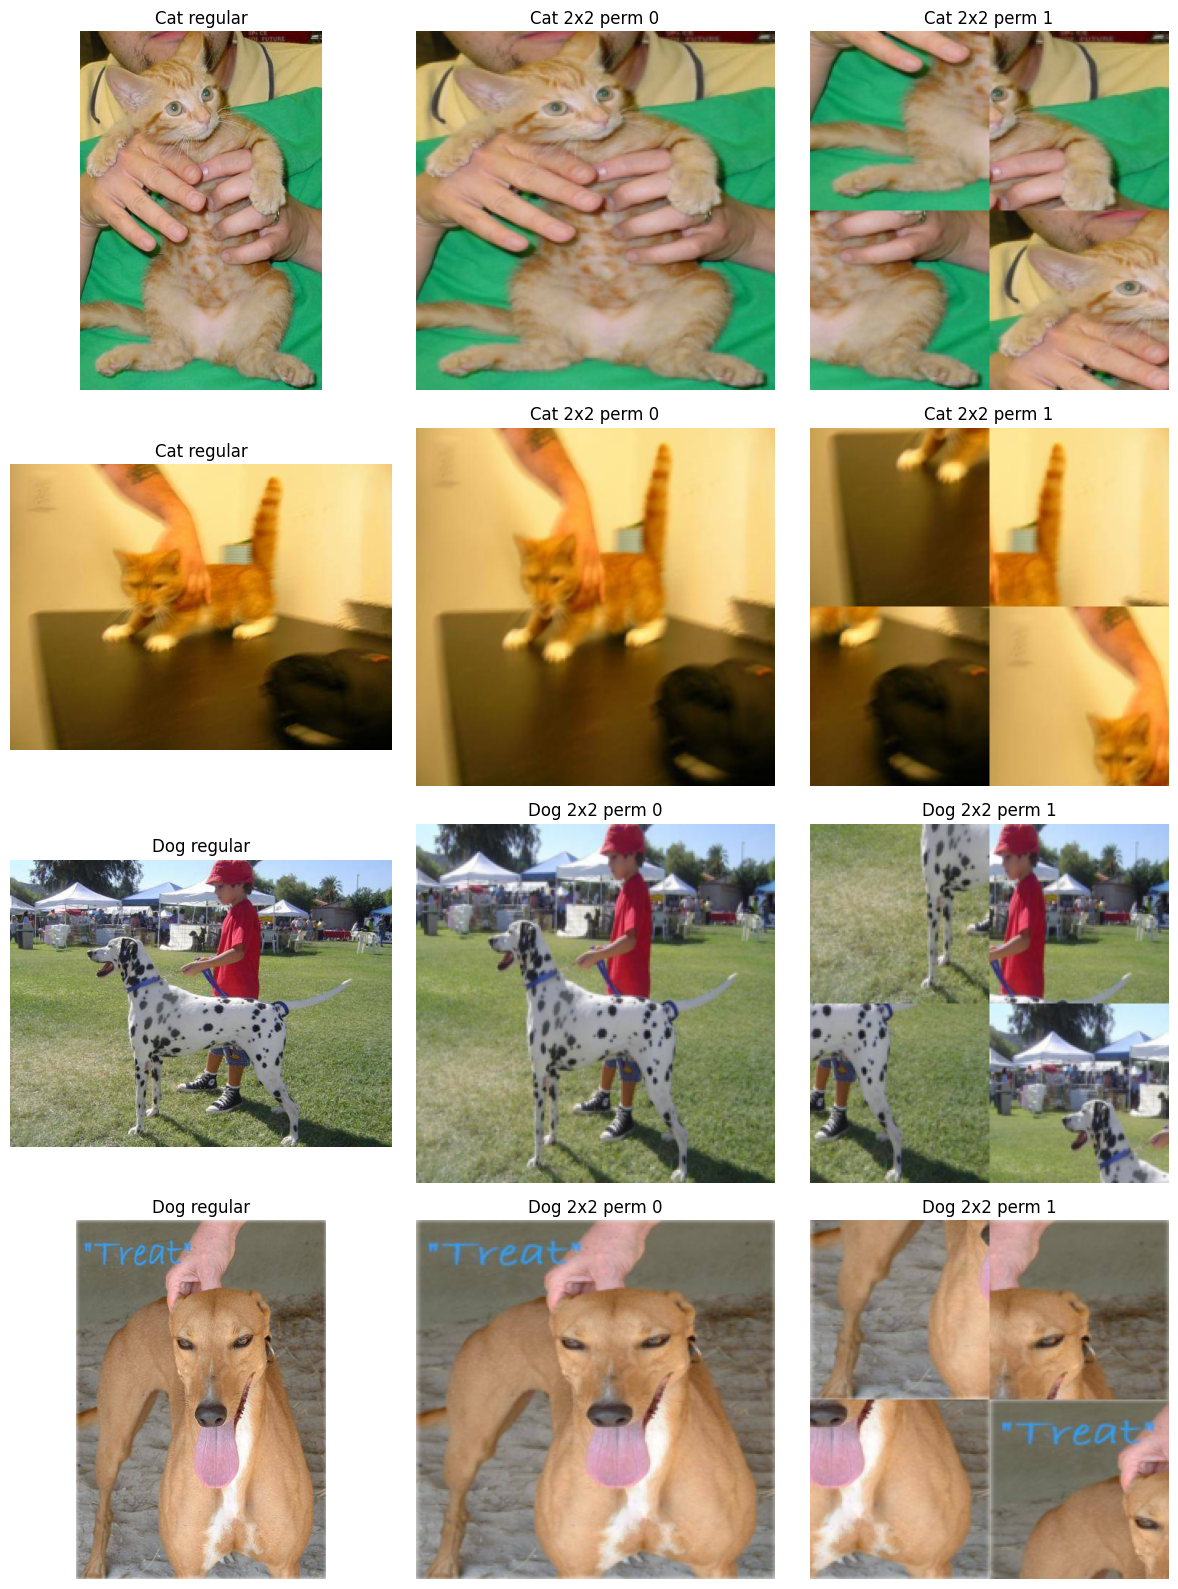

In [11]:
# Build and save permutation records
permutation_records = build_permutation_records(
    grid_sizes=configs.grid_sizes,
    num_permutations=configs.num_permutations,
    seed=configs.seed,
    include_identity=True,
)
permutation_rows = [record.__dict__ | {'permutation': json.dumps(record.permutation)} for record in permutation_records]
save_csv(data=permutation_rows, path=output_paths['permutations'])
print(f"Saved {len(permutation_records)} permutation records")

if configs.plot_samples:
    import matplotlib.pyplot as plt

    plot_permutation_samples(
        samples=train_samples,
        permutation_records=permutation_records,
        image_size=configs.image_size,
    )
    plt.show()


In [12]:
# Setup reproducibility and load data
seed = configs.seed
seed_everything(seed=seed, deterministic=configs.deterministic)
# Data already loaded above
print(f"Loaded {len(train_samples)} train, {len(validation_samples)} val samples")

Loaded 26 train, 6 val samples


In [13]:
# Prepare shared result accumulation across model runs
all_rows = []
run_id = configs.config_name

### Train ResNet18

In [14]:
model_name = "resnet18"
device = get_device(config=configs)
rows = collect_model_permutation_results(
    config=configs,
    model_name=model_name,
    run_id=run_id,
    train_samples=train_samples,
    validation_samples=validation_samples,
    permutation_records=permutation_records,
    seed=seed,
    device=device,
)
all_rows.extend(rows)
save_rows(rows=all_rows, output_path=output_paths['raw_results'])
print(f"Completed training ResNet18 with {len(rows)} runs")


[1/3] Running permutation grid=1x1, permutation_id=0, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'resnet18' on the current permutation...
Building training components for model 'resnet18'...
Finished building training components for model 'resnet18'.
Training model 'resnet18' for 1 epoch(s)...


Epoch:   0%|          | 0/1 [00:00<?, ?epoch/s]/Users/royrubin/Documents/GitHub/MLDS_Final_Project/src/training/engine.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp and device.type == "cuda")
/Users/royrubin/Documents/GitHub/MLDS_Final_Project/src/training/engine.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp and device.type == "cuda"):


Finished training model 'resnet18'. Metrics: {'train_loss': 0.7435385447282058, 'train_accuracy': 0.5769230769230769, 'val_loss': 1.834512710571289, 'val_accuracy': 0.5, 'best_val_accuracy': 0.5}
Done training model 'resnet18' on permutation_id=0.

[2/3] Running permutation grid=2x2, permutation_id=0, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'resnet18' on the current permutation...
Building training components for model 'resnet18'...
Finished building training components for model 'resnet18'.
Training model 'resnet18' for 1 epoch(s)...


Finished training model 'resnet18'. Metrics: {'train_loss': 0.674691915512085, 'train_accuracy': 0.5769230769230769, 'val_loss': 6.859055995941162, 'val_accuracy': 0.5, 'best_val_accuracy': 0.5}
Done training model 'resnet18' on permutation_id=0.

[3/3] Running permutation grid=2x2, permutation_id=1, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'resnet18' on the current permutation...
Building training components for model 'resnet18'...
Finished building training components for model 'resnet18'.
Training model 'resnet18' for 1 epoch(s)...


Finished training model 'resnet18'. Metrics: {'train_loss': 0.6294703896229084, 'train_accuracy': 0.6153846153846154, 'val_loss': 6.969390392303467, 'val_accuracy': 0.5, 'best_val_accuracy': 0.5}
Done training model 'resnet18' on permutation_id=1.
Completed training ResNet18 with 3 runs


### Train Swin-T

In [15]:
model_name = "swin_t"
rows = collect_model_permutation_results(
    config=configs,
    model_name=model_name,
    run_id=run_id,
    train_samples=train_samples,
    validation_samples=validation_samples,
    permutation_records=permutation_records,
    seed=seed,
    device=device,
)
all_rows.extend(rows)
save_rows(rows=all_rows, output_path=output_paths['raw_results'])
print(f"Completed training Swin-T with {len(rows)} runs")


[1/3] Running permutation grid=1x1, permutation_id=0, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'swin_t' on the current permutation...
Building training components for model 'swin_t'...
Finished building training components for model 'swin_t'.
Training model 'swin_t' for 1 epoch(s)...


Finished training model 'swin_t'. Metrics: {'train_loss': 1.9272592251117413, 'train_accuracy': 0.4230769230769231, 'val_loss': 1.2281453609466553, 'val_accuracy': 0.5, 'best_val_accuracy': 0.5}
Done training model 'swin_t' on permutation_id=0.

[2/3] Running permutation grid=2x2, permutation_id=0, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'swin_t' on the current permutation...
Building training components for model 'swin_t'...
Finished building training components for model 'swin_t'.
Training model 'swin_t' for 1 epoch(s)...


Finished training model 'swin_t'. Metrics: {'train_loss': 1.7048746622525728, 'train_accuracy': 0.46153846153846156, 'val_loss': 2.8067638874053955, 'val_accuracy': 0.3333333333333333, 'best_val_accuracy': 0.3333333333333333}
Done training model 'swin_t' on permutation_id=0.

[3/3] Running permutation grid=2x2, permutation_id=1, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'swin_t' on the current permutation...
Building training components for model 'swin_t'...
Finished building training components for model 'swin_t'.
Training model 'swin_t' for 1 epoch(s)...


Finished training model 'swin_t'. Metrics: {'train_loss': 2.2056523836576023, 'train_accuracy': 0.3076923076923077, 'val_loss': 2.3589065074920654, 'val_accuracy': 0.3333333333333333, 'best_val_accuracy': 0.3333333333333333}
Done training model 'swin_t' on permutation_id=1.
Completed training Swin-T with 3 runs


### Train ConvMixer

In [16]:
model_name = "convmixer"
rows = collect_model_permutation_results(
    config=configs,
    model_name=model_name,
    run_id=run_id,
    train_samples=train_samples,
    validation_samples=validation_samples,
    permutation_records=permutation_records,
    seed=seed,
    device=device,
)
all_rows.extend(rows)
save_rows(rows=all_rows, output_path=output_paths['raw_results'])
print(f"Completed training ConvMixer with {len(rows)} runs")


[1/3] Running permutation grid=1x1, permutation_id=0, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'convmixer' on the current permutation...
Building training components for model 'convmixer'...
Finished building training components for model 'convmixer'.
Training model 'convmixer' for 1 epoch(s)...


Finished training model 'convmixer'. Metrics: {'train_loss': 0.7087826682971075, 'train_accuracy': 0.4230769230769231, 'val_loss': 0.6934894919395447, 'val_accuracy': 0.5, 'best_val_accuracy': 0.5}
Done training model 'convmixer' on permutation_id=0.

[2/3] Running permutation grid=2x2, permutation_id=0, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'convmixer' on the current permutation...
Building training components for model 'convmixer'...
Finished building training components for model 'convmixer'.
Training model 'convmixer' for 1 epoch(s)...


Finished training model 'convmixer'. Metrics: {'train_loss': 0.6732962269049424, 'train_accuracy': 0.6538461538461539, 'val_loss': 0.6946480870246887, 'val_accuracy': 0.5, 'best_val_accuracy': 0.5}
Done training model 'convmixer' on permutation_id=0.

[3/3] Running permutation grid=2x2, permutation_id=1, seed=42
Building dataloaders...
Finished building dataloaders: 2 train batches, 1 validation batches.
Training model 'convmixer' on the current permutation...
Building training components for model 'convmixer'...
Finished building training components for model 'convmixer'.
Training model 'convmixer' for 1 epoch(s)...


Finished training model 'convmixer'. Metrics: {'train_loss': 0.7005311158987192, 'train_accuracy': 0.6153846153846154, 'val_loss': 0.6936870217323303, 'val_accuracy': 0.3333333333333333, 'best_val_accuracy': 0.3333333333333333}
Done training model 'convmixer' on permutation_id=1.
Completed training ConvMixer with 3 runs


In [17]:
# Aggregate results and plot
raw_results = pd.read_csv(filepath_or_buffer=output_paths['raw_results'])
aggregated_results = save_aggregated_accuracy(
    raw_results=raw_results,
    group_columns=['model_name', 'grid_size', 'num_tiles'],
    output_path=output_paths['aggregated_results'],
)
plot_accuracy_vs_tiles(aggregated=aggregated_results, output_path=output_paths['accuracy_plot'])
aggregated_results

,model_name,grid_size,num_tiles,mean_val_accuracy,std_val_accuracy,mean_best_val_accuracy,std_best_val_accuracy,n_runs
0,convmixer,1,1,0.500000,NaN,0.500000,NaN,1
1,convmixer,2,4,0.416667,0.117851,0.416667,0.117851,2
2,resnet18,1,1,0.500000,NaN,0.500000,NaN,1
3,resnet18,2,4,0.500000,0.000000,0.500000,0.000000,2
4,swin_t,1,1,0.500000,NaN,0.500000,NaN,1
5,swin_t,2,4,0.333333,0.000000,0.333333,0.000000,2


### Experiments - Results Table
Reload the saved aggregated CSV so the report is reproducible from disk.


In [18]:
saved_results = {
    'raw': pd.read_csv(filepath_or_buffer=output_paths['raw_results']),
    'aggregated': pd.read_csv(filepath_or_buffer=output_paths['aggregated_results']),
}
display(saved_results['aggregated'])

,model_name,grid_size,num_tiles,mean_val_accuracy,std_val_accuracy,mean_best_val_accuracy,std_best_val_accuracy,n_runs
0,convmixer,1,1,0.500000,NaN,0.500000,NaN,1
1,convmixer,2,4,0.416667,0.117851,0.416667,0.117851,2
2,resnet18,1,1,0.500000,NaN,0.500000,NaN,1
3,resnet18,2,4,0.500000,0.000000,0.500000,0.000000,2
4,swin_t,1,1,0.500000,NaN,0.500000,NaN,1
5,swin_t,2,4,0.333333,0.000000,0.333333,0.000000,2


### Experiments - Accuracy Plot
Display the saved accuracy-vs-number-of-tiles plot.


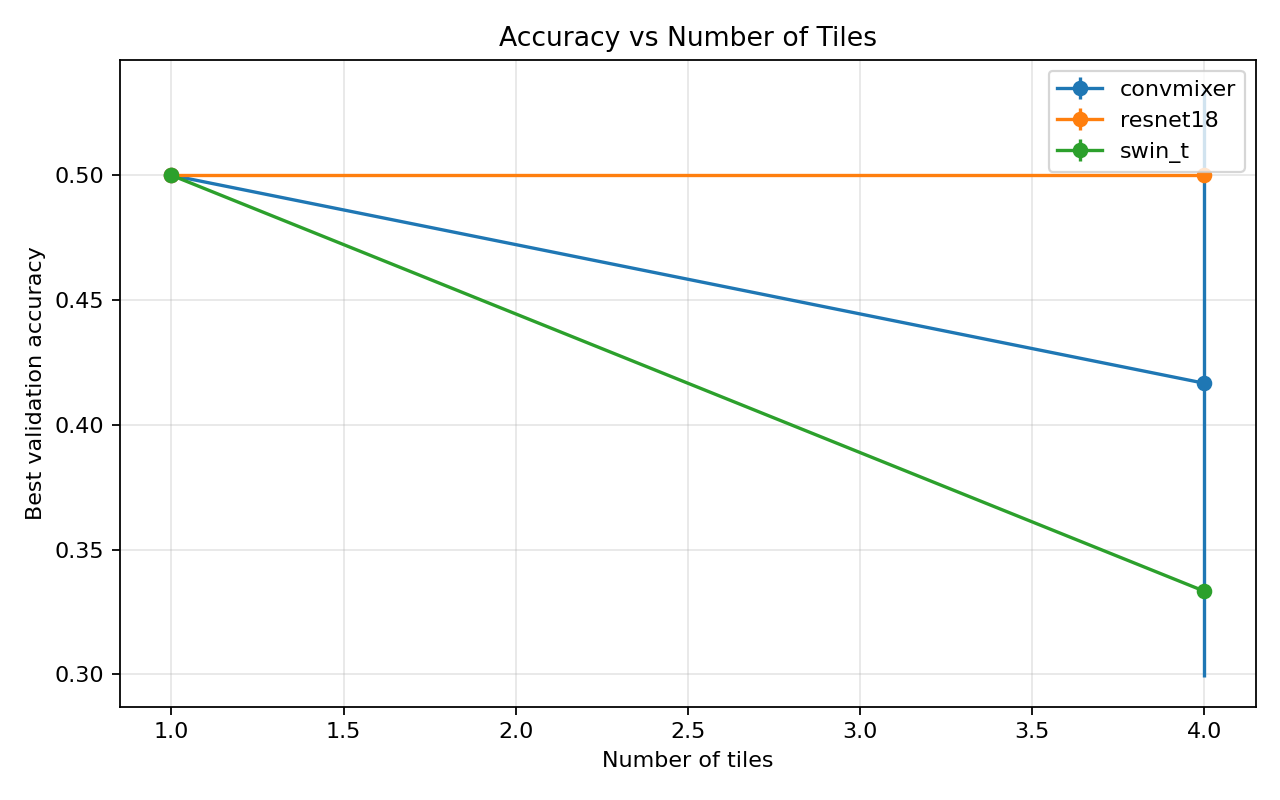

In [19]:
figure_path = output_paths['accuracy_plot']
if Path(figure_path).exists():
    display(Image(filename=figure_path))
else:
    print(f'Plot not found yet: {figure_path}')
